In [85]:
pip install pandas numpy matplotlib datascience

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aksha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datascience as ds
%matplotlib inline
movies = pd.read_csv('movies-1-1.csv')

In [87]:
movies = pd.read_csv('movies-1-1.csv')
rb = movies[movies['Title'].str.lower() == 'runaway bride']
num_words = rb['# Words'].values[0]
print(num_words)


4895


In [88]:

print(movies[movies['Title'].str.lower() == 'runaway bride']['it'].values[0])
print(movies[movies['Title'].str.lower() == 'runaway bride']['it'].values[0] * num_words)

0.0234092360077
114.588210258


In [89]:
vocab_table = pd.read_csv('stem-1-1.csv')
stemmed_message = vocab_table[vocab_table['Word'] == 'elements']['Stem'].values[0]
print(stemmed_message)

element


In [90]:
most_stem = vocab_table['Stem'].value_counts().idxmax()
print(most_stem)

gener


In [91]:
uncut_words = vocab_table[vocab_table['Word'] == vocab_table['Stem']]['Word']
max_len = uncut_words.str.len().max()
longest_uncut = uncut_words[uncut_words.str.len() == max_len].sort_values(ascending=False)
print(longest_uncut)
print(longest_uncut.iloc[0])

8290    iworkforacovertvaticanhumanitarian
Name: Word, dtype: object
iworkforacovertvaticanhumanitarian


In [92]:
count_single_stems = (vocab_table.groupby('Stem')['Word'].nunique() == 1).sum()
print(count_single_stems)

22594


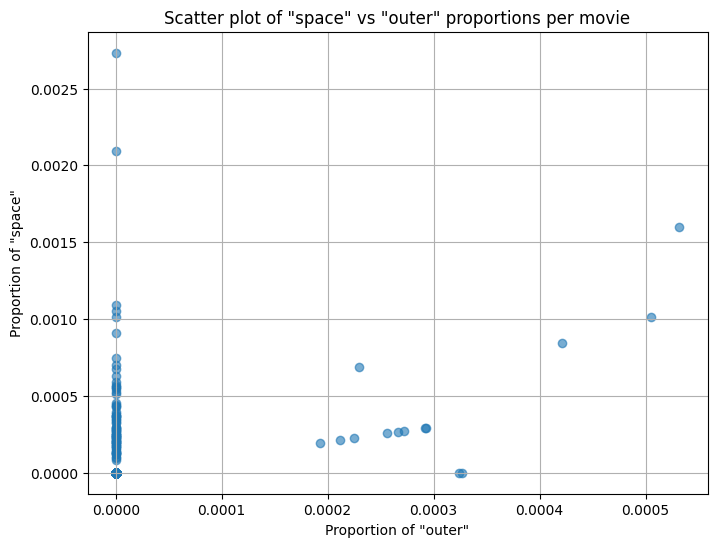

In [93]:
outer = movies['outer']
space = movies['space']

plt.figure(figsize=(8, 6))
plt.scatter(outer, space, alpha=0.6)
plt.xlabel('Proportion of "outer"')
plt.ylabel('Proportion of "space"')
plt.title('Scatter plot of "space" vs "outer" proportions per movie')
plt.grid(True)
plt.show()

In [94]:
r = outer.corr(space)
print(r)

0.319426078769


0.305469843087


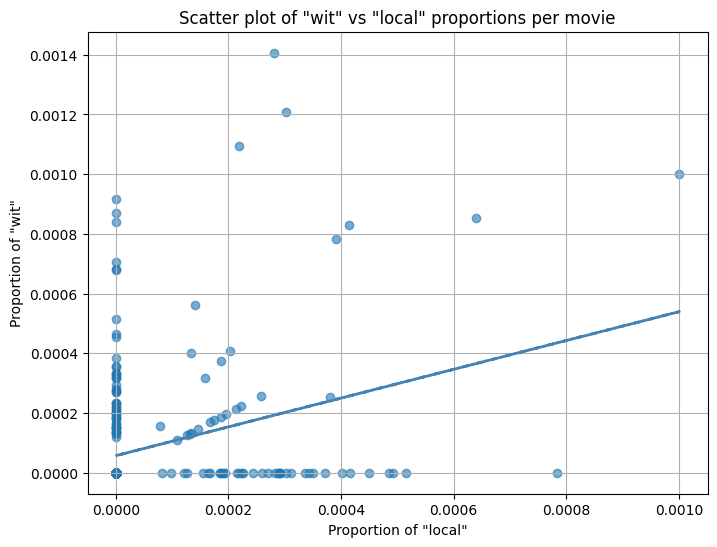

In [95]:
first_word = 'local'
second_word = 'wit'
first = movies[first_word]
second = movies[second_word]
print(first.corr(second))
m, b = np.polyfit(first, second, 1)


plt.figure(figsize=(8, 6))
plt.scatter(first, second, alpha=0.6)
plt.xlabel(f'Proportion of "{first_word}"')
plt.ylabel(f'Proportion of "{second_word}"')
plt.title(f'Scatter plot of "{second_word}" vs "{first_word}" proportions per movie')
plt.plot(first, m*first + b, color='steelblue', linestyle='--', linewidth=2, label='Best Fit Line')
plt.grid(True)
plt.show()

In [96]:
training_proportion = 17/20

num_movies = movies.shape[0]
num_train = int(num_movies * training_proportion)
num_test = num_movies - num_train

train_movies = movies.take(np.arange(num_train))
test_movies = movies.take(np.arange(num_train, num_movies))

print("Training: ",   train_movies.shape[0], ";",
      "Test: ",       test_movies.shape[0])



Training:  283 ; Test:  50


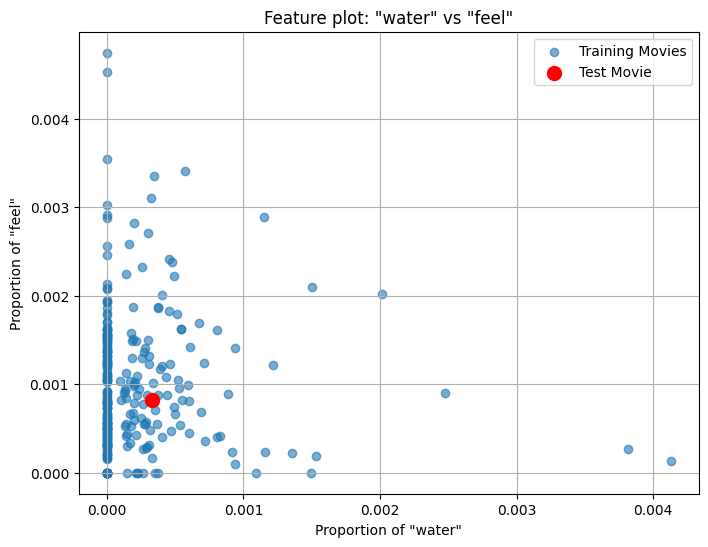

In [97]:
def plot_features(train_movies, test_movie, feature_x='water', feature_y='feel'):
    plt.figure(figsize=(8, 6))
    plt.scatter(train_movies[feature_x], train_movies[feature_y], alpha=0.6, label='Training Movies')
    
    plt.scatter(test_movie[feature_x], test_movie[feature_y], color='red', s=100, label='Test Movie')
    
    plt.xlabel(f'Proportion of "{feature_x}"')
    plt.ylabel(f'Proportion of "{feature_y}"')
    plt.title(f'Feature plot: "{feature_x}" vs "{feature_y}"')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_features(train_movies, test_movies.iloc[0])

In [98]:
def distance(movie1, movie2, feature_x='water', feature_y='feel'):
    x_diff = movie1[feature_x] - movie2[feature_x]
    y_diff = movie1[feature_y] - movie2[feature_y]
    return np.sqrt(x_diff**2 + y_diff**2)

monty_python_and_the_holy_grail = movies[movies['Title'].str.lower() == 'monty python and the holy grail'].iloc[0]
godfather = movies[movies['Title'].str.lower() == 'the godfather'].iloc[0]
print(distance(monty_python_and_the_holy_grail, godfather))

0.00122252091513


In [99]:
silence_of_the_lambs = movies[movies['Title'].str.lower() == 'the silence of the lambs'].iloc[0]
clerks = movies[movies['Title'].str.lower() == 'clerks.'].iloc[0]
print(distance(monty_python_and_the_holy_grail, silence_of_the_lambs))
print(distance(monty_python_and_the_holy_grail, clerks))

0.000222563148556
0.000798381068723


In [100]:

monty_python = monty_python_and_the_holy_grail
train_movies_copy = train_movies.copy()
train_movies_copy['distance from python'] = train_movies_copy.apply(
    lambda row: distance(row, monty_python, feature_x='water', feature_y='feel'), axis=1
)

close_movies = train_movies_copy.nsmallest(6, 'distance from python')[['Title', 'Genre', 'water', 'feel', 'distance from python']]
close_movies = close_movies[close_movies['Title'].str.lower() != 'monty python and the holy grail'].head(5)

print(close_movies)

                        Title     Genre     water      feel  \
256                     alien  thriller  0.000709  0.001241   
72        tomorrow never dies  thriller  0.000889  0.000889   
225  the silence of the lambs  thriller  0.000596  0.000993   
53                 innerspace    comedy  0.000522  0.001044   
274          some like it hot    comedy  0.000529  0.000951   

     distance from python  
256              0.000194  
72               0.000202  
225              0.000223  
53               0.000283  
274              0.000301  


In [101]:
def most_common(label, table):
    counts = table[label].value_counts()
    return counts.idxmax()

most_common('Genre', close_movies)

'thriller'

______________________________________________________________________________________________________________________________________________________

In [84]:
def distance(arr1, arr2):
    arr1 = np.array(arr1)
    arr2 = np.array(arr2)
    return np.sqrt(np.sum((arr1 - arr2) ** 2))

feature_cols = train_movies.columns[5:]
first_movie_features = train_movies.iloc[0][feature_cols].values
second_movie_features = train_movies.iloc[1][feature_cols].values
print(train_movies.iloc[0]['Title'])
print(train_movies.iloc[1]['Title'])
dist = distance(first_movie_features, second_movie_features)
print(round(dist, 3))

10 things i hate about you
sister act
0.033


In [80]:
distinguishers = ['kill','oh','marri', 'uh', 'great', 'waiter', 'cop', 'dead', 'murder', 'huh', 'ship']
train_my_features = train_movies[distinguishers]
test_my_features = test_movies[distinguishers]
print(train_my_features)

         kill        oh     marri        uh     great    waiter       cop  \
0    0.000398  0.002188  0.000000  0.000597  0.000995  0.000000  0.000000   
1    0.000704  0.002394  0.000141  0.000000  0.000563  0.000000  0.000422   
2    0.004118  0.004305  0.000000  0.001310  0.000000  0.000000  0.000374   
3    0.002316  0.002646  0.000331  0.000662  0.002646  0.000000  0.000000   
4    0.002196  0.000366  0.000000  0.000000  0.000000  0.000000  0.000000   
..        ...       ...       ...       ...       ...       ...       ...   
278  0.000270  0.008495  0.000539  0.000135  0.002967  0.000135  0.000000   
279  0.000454  0.003331  0.000151  0.000909  0.000757  0.000000  0.000000   
280  0.001096  0.000959  0.000411  0.000000  0.000274  0.000000  0.000411   
281  0.002119  0.001348  0.000193  0.000193  0.000963  0.000000  0.000193   
282  0.000920  0.003498  0.000184  0.000000  0.000552  0.000000  0.000000   

         dead    murder       huh      ship  
0    0.000398  0.000000  0.00

In [81]:
def fast_distances(test_row, train_table):

    counts_matrix = np.asmatrix(train_table.columns).transpose()
    diff = np.tile(np.array(list(test_row)), [counts_matrix.shape[0], 1]) - counts_matrix
    np.random.seed(0) # For tie breaking purposes
    distances = np.squeeze(np.asarray(np.sqrt(np.square(diff).sum(1))))
    eps = np.random.uniform(size=distances.shape)*1e-10 #Noise for tie break
    distances = distances + eps
    return distances

In [82]:

first_test_row = test_my_features.iloc[0].values

train_my_features_table = ds.Table.from_df(train_my_features)

distances = fast_distances(first_test_row, train_my_features_table)

genre_and_distances = pd.DataFrame({
    'Genre': train_movies['Genre'],
    'Distance': distances
})

# Sort by Distance
genre_and_distances = genre_and_distances.sort_values('Distance').reset_index(drop=True)

genre_and_distances.head()

,Genre,Distance
0,thriller,0.000981
1,thriller,0.001028
2,thriller,0.001048
3,thriller,0.001130
4,thriller,0.001232


In [83]:
# 7-nearest neighbors classification for the first test movie
k = 7
nearest_genres = genre_and_distances.head(k)['Genre']
predicted_genre = most_common('Genre', genre_and_distances.head(k))
actual_genre = test_movies.iloc[0]['Genre']
print("Predicted genre:", predicted_genre)
print("Actual genre:", actual_genre)
print("Correct?", predicted_genre == actual_genre)

def classify(test_row, train_features, train_labels, k):
    # Convert train_features to datascience Table if needed
    if isinstance(train_features, pd.DataFrame):
        train_features_table = ds.Table.from_df(train_features)
    else:
        train_features_table = train_features
    distances = fast_distances(test_row, train_features_table)
    # Get the k nearest labels
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = np.array(train_labels)[nearest_indices]
    # Return the most common label
    return pd.Series(nearest_labels).mode()[0]

godzilla_idx = test_movies[test_movies['Title'].str.lower().str.contains('godzilla')].index[0]
godzilla_features = test_my_features.iloc[godzilla_idx].values
godzilla_genre = classify(
    godzilla_features,
    train_my_features,
    train_movies['Genre'],
    15
)
print("Predicted genre for Godzilla:", godzilla_genre)

Predicted genre: thriller
Actual genre: comedy
Correct? False


IndexError: single positional indexer is out-of-bounds

In [ ]:
def classify_feature_row(row):
    return classify(
        row.values,
        train_my_features,
        train_movies['Genre'],
        15
    )

test_guesses = test_my_features.apply(classify_feature_row, axis=1).values

proportion_correct = np.mean(test_guesses == test_movies['Genre'].values)
print("Proportion correct:", round(proportion_correct, 2))

Proportion correct: 0.68


In [ ]:
test_movie_correctness = pd.DataFrame({
    'Title': test_movies['Title'],
    'Genre': test_movies['Genre'],
    'Was correct': test_guesses == test_movies['Genre'].values
})
test_movie_correctness.head()

,Title,Genre,Was correct
283,ghostbusters ii,comedy,True
284,intolerable cruelty,comedy,True
285,psycho,thriller,False
286,book of shadows: blair witch 2,thriller,True
287,the getaway,thriller,True


In [ ]:
# Load your friends' movie data
friend_movies = pd.read_csv('friend_movies-1-1.csv')

# Choose up to 5 new features (words) for the classifier
# Here, let's pick 5 features that might be good at distinguishing comedy and thriller
new_features = np.array(['wit', 'kill', 'oh', 'cop', 'dead'])

# Prepare the training and friend test feature sets
train_new_features = train_movies[new_features]
friend_test_features = friend_movies[new_features]

# Define the new classifier function
def another_classifier(row):
    return classify(
        row.values,
        train_new_features,
        train_movies['Genre'],
        7  # You can try different values of k here
    )

# Predict genres for your friends' movies
friend_guesses = friend_test_features.apply(another_classifier, axis=1).values

# Calculate accuracy for your friends' dataset
friend_accuracy = np.mean(friend_guesses == friend_movies['Genre'].values)
print("Accuracy on friends' movies with new classifier:", round(friend_accuracy, 2))

Accuracy on friends' movies with new classifier: 0.78


In [ ]:
friend_movie_correctness = pd.DataFrame({
    'Title': friend_movies['Title'],
    'Genre': friend_movies['Genre'],
    'Was correct': friend_guesses == friend_movies['Genre'].values
})
friend_movie_correctness.head()

,Title,Genre,Was correct
0,black rain,thriller,True
1,bringing out the dead,thriller,True
2,basic,thriller,True
3,detroit rock city,comedy,False
4,panic room,thriller,True
